In [1]:
# ============================================================
# DIM ASSETS - Generación Automática desde Tickers
# ============================================================

import yfinance as yf
import sqlite3 # Importar la librería sqlite3
import pandas as pd # Importar pandas para pd.read_sql

# Crear una conexión a una base de datos SQLite en memoria
conn = sqlite3.connect(':memory:')

# ✅ ÚNICA LÍNEA QUE TOCÁS
tickers = ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'META', 'AMZN', 'AMD', 'AVGO', 'QCOM', 'INTC']

# Metadatos manuales para ETFs (yfinance no los devuelve)
ETF_METADATA = {
    'GLD': ('SPDR Gold Shares', 'Commodities', 'Precious Metals'),
    'SLV': ('iShares Silver Trust', 'Commodities', 'Precious Metals'),
    'GDX': ('VanEck Gold Miners ETF', 'Commodities', 'Gold Mining'),
    'XLK': ('Technology Select Sector SPDR', 'ETF', 'Technology'),
    'XLE': ('Energy Select Sector SPDR', 'ETF', 'Energy'),
    'XLF': ('Financial Select Sector SPDR', 'ETF', 'Financials'),
    'XLV': ('Health Care Select Sector SPDR', 'ETF', 'Health Care'),
    'XLI': ('Industrial Select Sector SPDR', 'ETF', 'Industrials'),
}

def build_dim_assets(tickers):
    print(f"🔍 Obteniendo metadatos para {len(tickers)} activos...")
    assets_data = []

    for ticker in tickers:
        if ticker in ETF_METADATA:
            name, sector, industry = ETF_METADATA[ticker]
            assets_data.append((ticker, name, sector, industry))
            print(f"  ✅ {ticker} → {sector} / {industry} (ETF hardcodeado)")
        else:
            try:
                info = yf.Ticker(ticker).info
                name     = info.get('longName', ticker)
                sector   = info.get('sector', 'Unknown')
                industry = info.get('industry', 'Unknown')
                assets_data.append((ticker, name, sector, industry))
                print(f"  ✅ {ticker} → {sector} / {industry}")
            except Exception as e:
                assets_data.append((ticker, ticker, 'Unknown', 'Unknown'))
                print(f"  ⚠️ {ticker} → Error al obtener info: {e}")

    return assets_data


def save_dim_assets(conn, assets_data):
    cursor = conn.cursor()
    cursor.execute("DROP TABLE IF EXISTS Dim_Assets")  # ← línea nueva
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS Dim_Assets (
            ticker  TEXT PRIMARY KEY,
            name    TEXT,
            sector  TEXT,
            industry TEXT
        )
    ''')
    cursor.executemany("INSERT OR REPLACE INTO Dim_Assets VALUES (?, ?, ?, ?)", assets_data)
    conn.commit()
    print(f"\n✅ Dim_Assets guardada con {len(assets_data)} activos.")


# --- Ejecución ---
assets_data = build_dim_assets(tickers)
save_dim_assets(conn, assets_data)

# --- Vista previa ---
df_dim = pd.read_sql("SELECT * FROM Dim_Assets", conn)
display(df_dim)

🔍 Obteniendo metadatos para 10 activos...
  ✅ AAPL → Technology / Consumer Electronics
  ✅ MSFT → Technology / Software - Infrastructure
  ✅ GOOGL → Communication Services / Internet Content & Information
  ✅ NVDA → Technology / Semiconductors
  ✅ META → Communication Services / Internet Content & Information
  ✅ AMZN → Consumer Cyclical / Internet Retail
  ✅ AMD → Technology / Semiconductors
  ✅ AVGO → Technology / Semiconductors
  ✅ QCOM → Technology / Semiconductors
  ✅ INTC → Technology / Semiconductors

✅ Dim_Assets guardada con 10 activos.


,ticker,name,sector,industry
0,AAPL,Apple Inc.,Technology,Consumer Electronics
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure
2,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information
3,NVDA,NVIDIA Corporation,Technology,Semiconductors
4,META,"Meta Platforms, Inc.",Communication Services,Internet Content & Information
5,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail
6,AMD,"Advanced Micro Devices, Inc.",Technology,Semiconductors
7,AVGO,Broadcom Inc.,Technology,Semiconductors
8,QCOM,QUALCOMM Incorporated,Technology,Semiconductors
9,INTC,Intel Corporation,Technology,Semiconductors


In [2]:
from datetime import datetime
def ingest_bronze_10years(tickers):
    print(f"Iniciando descarga de 10 años para {len(tickers)} activos...")

    end_date = datetime.now().strftime('%Y-%m-%d')
    start_date = (datetime.now().replace(year=datetime.now().year - 10)).strftime('%Y-%m-%d')

    raw_data = yf.download(tickers, start=start_date, end=end_date)

    bronze_prices = raw_data['Close'].stack(future_stack=True).reset_index()
    bronze_prices.columns = ['date', 'ticker', 'adj_close']

    bronze_volume = raw_data['Volume'].stack(future_stack=True).reset_index()
    bronze_volume.columns = ['date', 'ticker', 'volume']

    bronze_final = pd.merge(bronze_prices, bronze_volume, on=['date', 'ticker'])

    bronze_final.to_sql('bronze_market_data', conn, if_exists='replace', index=False)

    print(f"✅ Capa Bronze completada: {len(bronze_final)} filas guardadas en SQL.")
    return bronze_final

In [3]:
cursor = conn.cursor()
cursor.execute("DROP TABLE IF EXISTS bronze_market_data")
conn.commit()
df_bronze = ingest_bronze_10years(tickers)

Iniciando descarga de 10 años para 10 activos...


/tmp/ipykernel_731/1349626895.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  10 of 10 completed


✅ Capa Bronze completada: 25130 filas guardadas en SQL.


In [4]:
# 1. Ver las primeras 10 filas para entender la estructura
query_preview = "SELECT * FROM bronze_market_data LIMIT 10;"
df_preview = pd.read_sql(query_preview, conn)

print("--- Vista Previa de los Datos (Primeras 11 filas) ---")
display(df_preview)

# 2. Resumen estadístico básico por Activo
# Esto te dirá cuántos días de datos tienes por cada ticker y sus precios promedio
query_summary = """
SELECT
    ticker,
    COUNT(*) as total_dias,
    MIN(date) as fecha_inicio,
    MAX(date) as fecha_fin,
    AVG(adj_close) as precio_promedio,
    MAX(adj_close) as precio_maximo
FROM bronze_market_data
GROUP BY ticker;
"""
df_summary = pd.read_sql(query_summary, conn)

print("\n--- Resumen de los 10 años por Activo ---")
display(df_summary)

--- Vista Previa de los Datos (Primeras 11 filas) ---


,date,ticker,adj_close,volume
0,2016-03-09 00:00:00,AAPL,22.901699,108806800
1,2016-03-09 00:00:00,AMD,2.260000,13082400
2,2016-03-09 00:00:00,AMZN,27.973499,87546000
3,2016-03-09 00:00:00,AVGO,10.852188,31152000
4,2016-03-09 00:00:00,GOOGL,35.998505,39544000
5,2016-03-09 00:00:00,INTC,24.611740,14707800
6,2016-03-09 00:00:00,META,106.764221,20493300
7,2016-03-09 00:00:00,MSFT,46.493336,28251600
8,2016-03-09 00:00:00,NVDA,0.776796,222788000
9,2016-03-09 00:00:00,QCOM,39.310284,13964500



--- Resumen de los 10 años por Activo ---


,ticker,total_dias,fecha_inicio,fecha_fin,precio_promedio,precio_maximo
0,AAPL,2513,2016-03-09 00:00:00,2026-03-06 00:00:00,118.439354,285.922455
1,AMD,2513,2016-03-09 00:00:00,2026-03-06 00:00:00,77.324345,264.329987
2,AMZN,2513,2016-03-09 00:00:00,2026-03-06 00:00:00,124.034836,254.000000
3,AVGO,2513,2016-03-09 00:00:00,2026-03-06 00:00:00,75.323684,412.181335
4,GOOGL,2513,2016-03-09 00:00:00,2026-03-06 00:00:00,105.035969,343.690002
5,INTC,2513,2016-03-09 00:00:00,2026-03-06 00:00:00,37.559805,62.083324
6,META,2513,2016-03-09 00:00:00,2026-03-06 00:00:00,288.361695,788.823792
7,MSFT,2513,2016-03-09 00:00:00,2026-03-06 00:00:00,229.096968,539.825195
8,NVDA,2513,2016-03-09 00:00:00,2026-03-06 00:00:00,39.298628,207.028473
9,QCOM,2513,2016-03-09 00:00:00,2026-03-06 00:00:00,100.395600,218.423676


In [5]:
# ============================================================
# CAPA SILVER
# ============================================================

cursor = conn.cursor()

sql_silver_transform = """
CREATE TABLE IF NOT EXISTS silver_market_data AS
SELECT DISTINCT
    b.date,
    b.ticker,
    a.sector,
    b.adj_close,
    (b.adj_close / LAG(b.adj_close) OVER (PARTITION BY b.ticker ORDER BY b.date) - 1) AS daily_return,
    AVG(b.volume) OVER (PARTITION BY b.ticker ORDER BY b.date ROWS BETWEEN 9 PRECEDING AND CURRENT ROW) AS avg_vol_10d
FROM bronze_market_data b
JOIN Dim_Assets a ON b.ticker = a.ticker;
"""

cursor.execute("DROP TABLE IF EXISTS silver_market_data")
conn.commit()  # ← commit después del DROP
cursor.execute(sql_silver_transform)
conn.commit()

query_silver_full = """
SELECT
    date, ticker, sector, adj_close,
    ROUND(daily_return * 100, 2) as daily_return_pct,
    ROUND(avg_vol_10d, 0) as avg_vol_10d
FROM silver_market_data
WHERE daily_return IS NOT NULL
ORDER BY date DESC, daily_return DESC
LIMIT 20;
"""
df_silver = pd.read_sql(query_silver_full, conn)
print("--- EXPLORACIÓN DE LA CAPA SILVER ---")
display(df_silver)

query_nulls = "SELECT ticker, COUNT(*) as nulos FROM silver_market_data WHERE daily_return IS NULL GROUP BY ticker;"
df_nulls = pd.read_sql(query_nulls, conn)
print("\n--- Nulos en Daily_Return por Ticker ---")
display(df_nulls)

query_sector_perf = """
SELECT
    sector,
    ROUND(AVG(daily_return) * 100, 4) as avg_daily_ret_pct,
    ROUND(AVG(daily_return * daily_return), 6) as variance_proxy
FROM silver_market_data
GROUP BY sector
ORDER BY avg_daily_ret_pct DESC;
"""
display(pd.read_sql(query_sector_perf, conn))

--- EXPLORACIÓN DE LA CAPA SILVER ---


,date,ticker,sector,adj_close,daily_return_pct,avg_vol_10d
0,2026-03-06 00:00:00,MSFT,Technology,408.959991,-0.42,38609000.0
1,2026-03-06 00:00:00,AVGO,Technology,330.480011,-0.69,29376810.0
2,2026-03-06 00:00:00,GOOGL,Communication Services,298.519989,-0.78,32919590.0
3,2026-03-06 00:00:00,QCOM,Technology,135.690002,-0.96,9460810.0
4,2026-03-06 00:00:00,AAPL,Technology,257.459991,-1.09,43370120.0
5,2026-03-06 00:00:00,META,Communication Services,644.859985,-2.38,11577280.0
6,2026-03-06 00:00:00,AMZN,Consumer Cyclical,213.210007,-2.62,49719540.0
7,2026-03-06 00:00:00,NVDA,Technology,177.820007,-3.01,222196790.0
8,2026-03-06 00:00:00,AMD,Technology,192.429993,-3.52,40310900.0
9,2026-03-06 00:00:00,INTC,Technology,43.419998,-5.51,77643390.0



--- Nulos en Daily_Return por Ticker ---


,ticker,nulos
0,AAPL,1
1,AMD,1
2,AMZN,1
3,AVGO,1
4,GOOGL,1
5,INTC,1
6,META,1
7,MSFT,1
8,NVDA,1
9,QCOM,1


,sector,avg_daily_ret_pct,variance_proxy
0,Technology,0.1461,0.000689
1,Consumer Cyclical,0.1017,0.000419
2,Communication Services,0.1008,0.000455


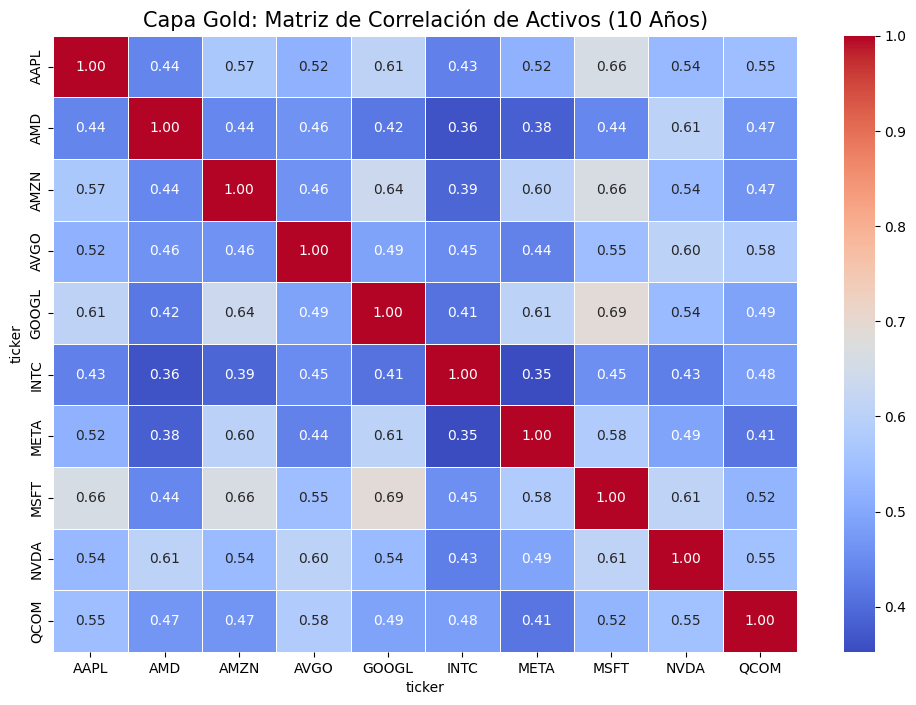

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

query_gold = "SELECT date, ticker, daily_return FROM silver_market_data WHERE daily_return IS NOT NULL"
df_gold = pd.read_sql(query_gold, conn)

pivot_retornos = df_gold.pivot(index='date', columns='ticker', values='daily_return')
corr_matrix = pivot_retornos.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Capa Gold: Matriz de Correlación de Activos (10 Años)', fontsize=15)
plt.show()

In [7]:
import numpy as np

retornos_anuales = pivot_retornos.mean() * 252
cov_matriz = pivot_retornos.cov() * 252

# Get the list of actual tickers from the pivot table
available_tickers = pivot_retornos.columns

num_portafolios = 5000
resultados = np.zeros((3, num_portafolios))
pesos_lista = []

for i in range(num_portafolios):
    # Adjust the number of pesos to match the available tickers in retornos_anuales
    pesos = np.random.random(len(available_tickers))
    pesos /= np.sum(pesos)
    pesos_lista.append(pesos)
    retorno_p = np.dot(pesos, retornos_anuales)
    volatilidad_p = np.sqrt(np.dot(pesos.T, np.dot(cov_matriz, pesos)))
    resultados[0,i] = retorno_p
    resultados[1,i] = volatilidad_p
    resultados[2,i] = resultados[0,i] / resultados[1,i]

ind_max_sharpe = np.argmax(resultados[2])
mejores_pesos = pesos_lista[ind_max_sharpe]

print("--- RESULTADOS DE LA OPTIMIZACIÓN (CAPA GOLD) ---")
# Use available_tickers for printing to match the optimized weights
for t, p in zip(available_tickers, mejores_pesos):
    print(f"{t}: {p*100:.2f}%")
print(f"\nRetorno Esperado Anual: {resultados[0,ind_max_sharpe]*100:.2f}%")
print(f"Volatilidad Anual (Riesgo): {resultados[1,ind_max_sharpe]*100:.2f}%")

--- RESULTADOS DE LA OPTIMIZACIÓN (CAPA GOLD) ---
AAPL: 7.53%
AMD: 4.84%
AMZN: 9.59%
AVGO: 22.55%
GOOGL: 1.07%
INTC: 1.21%
META: 3.10%
MSFT: 11.41%
NVDA: 37.83%
QCOM: 0.86%

Retorno Esperado Anual: 46.60%
Volatilidad Anual (Riesgo): 33.83%


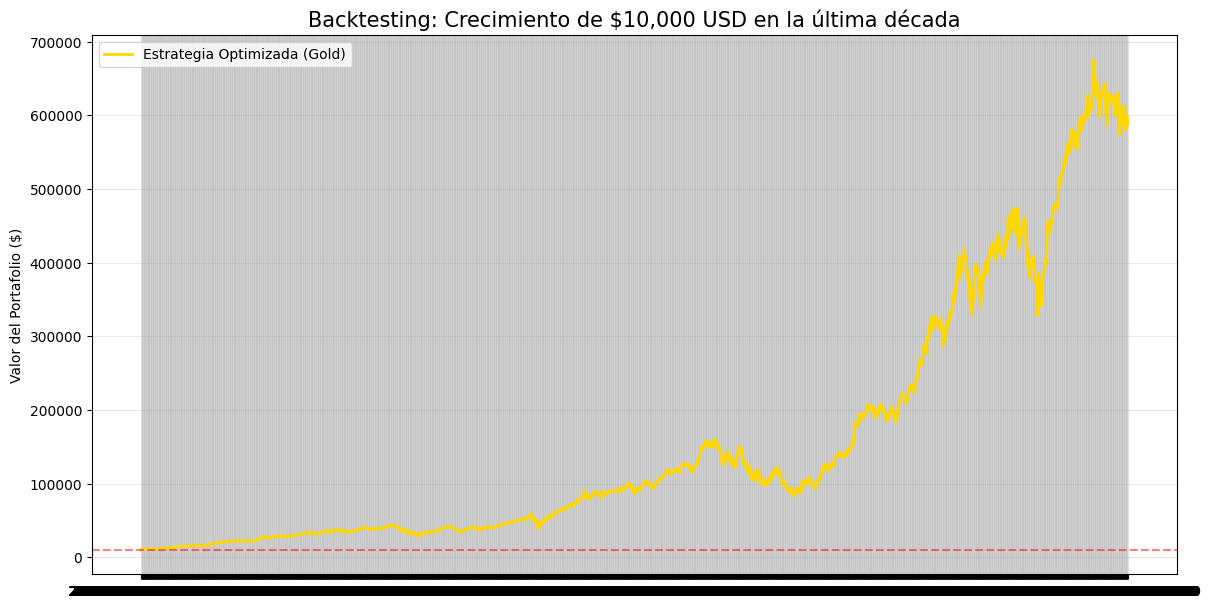

/tmp/ipykernel_731/935287197.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Valor final del portafolio: ${crecimiento_portafolio[-1]:,.2f}")
/tmp/ipykernel_731/935287197.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Retorno total: {((crecimiento_portafolio[-1]/capital_inicial)-1)*100:.2f}%")


Valor final del portafolio: $586,320.95
Retorno total: 5763.21%


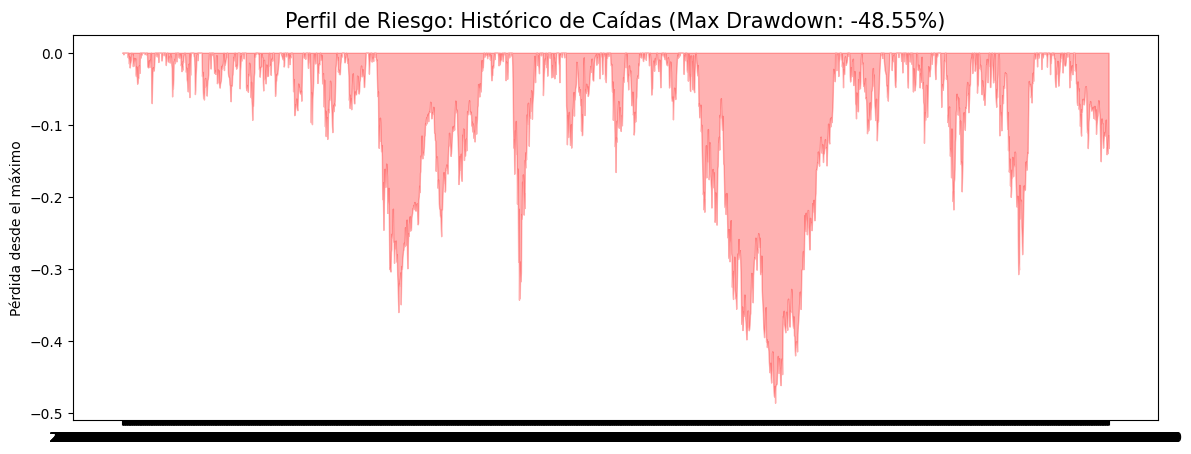

La mayor caída que sufrió este portafolio fue del: -48.55%


In [8]:
portafolio_retorno_diario = (pivot_retornos * mejores_pesos).sum(axis=1)
capital_inicial = 10000
crecimiento_portafolio = capital_inicial * (1 + portafolio_retorno_diario).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(crecimiento_portafolio, label='Estrategia Optimizada (Gold)', color='gold', linewidth=2)
plt.axhline(y=capital_inicial, color='red', linestyle='--', alpha=0.5)
plt.title('Backtesting: Crecimiento de $10,000 USD en la última década', fontsize=15)
plt.ylabel('Valor del Portafolio ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Valor final del portafolio: ${crecimiento_portafolio[-1]:,.2f}")
print(f"Retorno total: {((crecimiento_portafolio[-1]/capital_inicial)-1)*100:.2f}%")

picos = crecimiento_portafolio.cummax()
drawdowns = (crecimiento_portafolio - picos) / picos
max_drawdown = drawdowns.min()

plt.figure(figsize=(14, 5))
plt.fill_between(drawdowns.index, drawdowns, color='red', alpha=0.3)
plt.title(f'Perfil de Riesgo: Histórico de Caídas (Max Drawdown: {max_drawdown*100:.2f}%)', fontsize=15)
plt.ylabel('Pérdida desde el máximo')
plt.show()

print(f"La mayor caída que sufrió este portafolio fue del: {max_drawdown*100:.2f}%")

/tmp/ipykernel_731/2001781275.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_data = yf.download('SPY', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


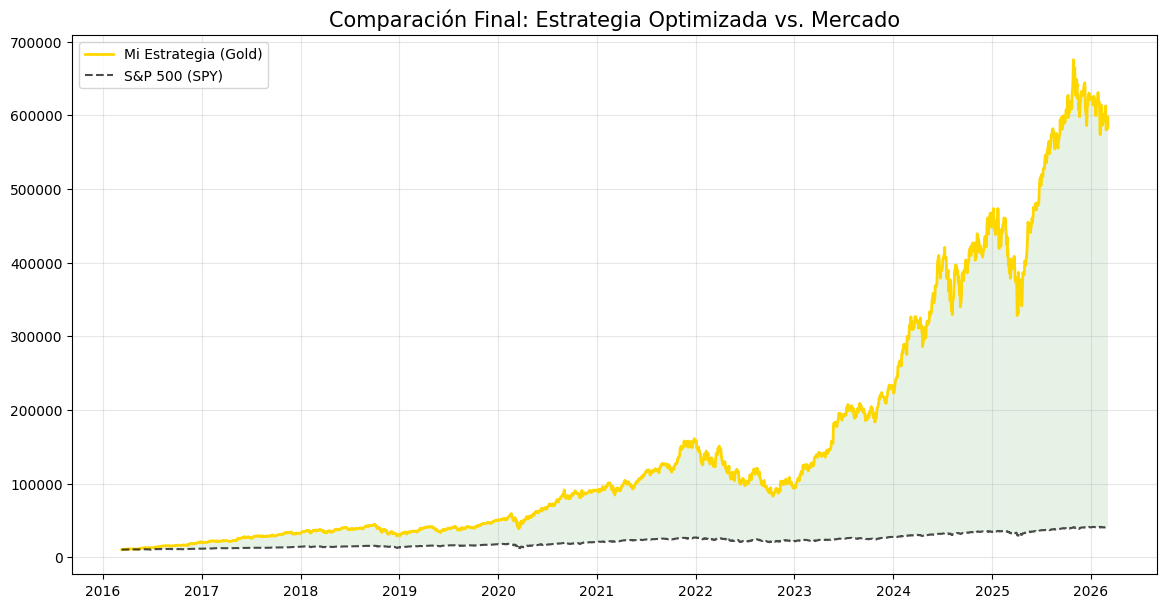

Retorno Final Estrategia: 5763.21%
Retorno Final SPY: 297.90%
Alpha (Ventaja sobre el mercado): 5465.31%


In [9]:
from datetime import datetime

end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now().replace(year=datetime.now().year - 10)).strftime('%Y-%m-%d')

spy_data = yf.download('SPY', start=start_date, end=end_date)
spy_daily_ret = spy_data['Close'].pct_change().dropna()

portafolio_ret_df = portafolio_retorno_diario.to_frame(name='ret_portafolio')
portafolio_ret_df.index = pd.to_datetime(portafolio_ret_df.index)

spy_ret_df = spy_daily_ret.copy()
spy_ret_df.columns = ['ret_spy']
spy_ret_df.index = pd.to_datetime(spy_ret_df.index)

df_comparacion = portafolio_ret_df.merge(spy_ret_df, left_index=True, right_index=True, how='inner')

capital_inicial = 10000
df_comparacion['crecimiento_port'] = capital_inicial * (1 + df_comparacion['ret_portafolio']).cumprod()
df_comparacion['crecimiento_spy'] = capital_inicial * (1 + df_comparacion['ret_spy']).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(df_comparacion['crecimiento_port'], label='Mi Estrategia (Gold)', color='#FFD700', linewidth=2)
plt.plot(df_comparacion['crecimiento_spy'], label='S&P 500 (SPY)', color='black', linestyle='--', alpha=0.7)
plt.fill_between(df_comparacion.index, df_comparacion['crecimiento_port'], df_comparacion['crecimiento_spy'],
                 where=(df_comparacion['crecimiento_port'] > df_comparacion['crecimiento_spy']),
                 facecolor='green', alpha=0.1)
plt.title('Comparación Final: Estrategia Optimizada vs. Mercado', fontsize=15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

ret_total_port = ((df_comparacion['crecimiento_port'].iloc[-1] / capital_inicial) - 1) * 100
ret_total_spy = ((df_comparacion['crecimiento_spy'].iloc[-1] / capital_inicial) - 1) * 100
print(f"Retorno Final Estrategia: {ret_total_port:.2f}%")
print(f"Retorno Final SPY: {ret_total_spy:.2f}%")
print(f"Alpha (Ventaja sobre el mercado): {ret_total_port - ret_total_spy:.2f}%")

In [10]:
cursor = conn.cursor()
cursor.execute("DROP TABLE IF EXISTS gold_final_metrics")
cursor.execute('''
    CREATE TABLE IF NOT EXISTS gold_final_metrics (
        metric_name TEXT,
        value REAL,
        comparison_target TEXT,
        date_calculated DATE
    )
''')

fecha_hoy = datetime.now().strftime('%Y-%m-%d')
metricas = [
    ('Final_Return_Strategy', round(ret_total_port, 2), 'Portfolio', fecha_hoy),
    ('Final_Return_SPY', round(ret_total_spy, 2), 'Benchmark', fecha_hoy),
    ('Alpha', round(ret_total_port - ret_total_spy, 2), 'Excess_Return', fecha_hoy),
    ('Max_Drawdown', round(max_drawdown * 100, 2), 'Risk_Metric', fecha_hoy)
]

cursor.executemany("INSERT INTO gold_final_metrics VALUES (?, ?, ?, ?)", metricas)
conn.commit()
print("✅ Proyecto Finalizado: Métricas guardadas en la base de datos.")

✅ Proyecto Finalizado: Métricas guardadas en la base de datos.


In [11]:
from datetime import datetime

# ============================================================
# CAPA GOLD — Métricas Finales (Dinámicas)
# ============================================================

cursor = conn.cursor()
cursor.execute("DROP TABLE IF EXISTS gold_final_metrics")
cursor.execute('''
    CREATE TABLE IF NOT EXISTS gold_final_metrics (
        metric_name TEXT,
        value REAL,
        comparison_target TEXT,
        date_calculated DATE
    )
''')

fecha_hoy = datetime.now().strftime('%Y-%m-%d')
cap_ini = 10000

metricas = [
    ('Final_Return_Strategy', round(ret_total_port, 2), 'Portfolio', fecha_hoy),
    ('Final_Return_SPY',      round(ret_total_spy, 2),  'Benchmark', fecha_hoy),
    ('Alpha',                 round(ret_total_port - ret_total_spy, 2), 'Excess_Return', fecha_hoy),
    ('Max_Drawdown',          round(max_drawdown * 100, 2), 'Risk_Metric', fecha_hoy)
]

cursor.executemany("INSERT INTO gold_final_metrics VALUES (?, ?, ?, ?)", metricas)
conn.commit()
print("✅ Métricas guardadas dinámicamente.")

# ── Variables para el Dashboard ──────────────────────────────

# 1. KPIs verticales
df_kpis_vertical = pd.DataFrame({
    'Métrica': ['Capital Final (USD)', 'Retorno Estrategia (%)', 'Retorno S&P 500 (%)', 'Alpha (%)', 'Max Drawdown (%)'],
    'Valor':   [
        crecimiento_portafolio.iloc[-1],
        ret_total_port / 100,
        ret_total_spy / 100,
        (ret_total_port - ret_total_spy) / 100,
        max_drawdown
    ]
})

# 2. Histórico anual
port_anual = crecimiento_portafolio.copy()
port_anual.index = pd.to_datetime(port_anual.index)
spy_anual = df_comparacion['crecimiento_spy'].copy()
spy_anual.index = pd.to_datetime(spy_anual.index)

df_hist_anual = pd.DataFrame({
    'Año':       port_anual.resample('YE').last().index.year,
    'Estrategia': port_anual.resample('YE').last().values,
    'Mercado':    spy_anual.resample('YE').last().values
})

# 3. Ganancia por sector
sector_map = pd.read_sql("SELECT ticker, sector FROM Dim_Assets", conn).set_index('ticker')['sector'].to_dict()
ganancia_por_sector = (
    (pivot_retornos * mejores_pesos)
    .rename(columns=sector_map)
    .groupby(level=0, axis=1).sum()
    .add(1).cumprod()
    .iloc[-1] * cap_ini - cap_ini
)
df_rubros = ganancia_por_sector.reset_index()
df_rubros.columns = ['Rubro', 'Ganancia_USD']

# 4. Participación por ticker (pesos óptimos)
df_pie = pd.DataFrame({
    'Ticker':        list(pivot_retornos.columns),
    'Participacion': mejores_pesos
})

# 5. Path para guardar (Google Drive o local)
path = '/content/'

print("✅ Variables del dashboard listas.")

✅ Métricas guardadas dinámicamente.
✅ Variables del dashboard listas.


/tmp/ipykernel_731/2955178637.py:63: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(level=0, axis=1).sum()


In [12]:
# ============================================================
# 🚀 DASHBOARD DARK TECH - Estilo Cyberpunk Financiero
# ============================================================

!pip install plotly -q

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from datetime import datetime
from IPython.display import display, HTML

fecha_hoy = datetime.today().strftime('%d/%m/%Y')

# ── PALETA DARK TECH ──────────────────────────────────────────
C_BG         = "#0D1117"
C_CARD       = "#0D1F2D"
C_CARD2      = "#0A1929"
C_CYAN       = "#00E5FF"
C_CYAN_DIM   = "#00B8CC"
C_TEAL       = "#00FFB3"
C_GRID       = "#1A2E3B"
C_BORDER     = "#1E3A4A"
C_TEXTO      = "#E0F7FA"
C_SUBTEXTO   = "#546E7A"
C_ROJO       = "#FF1744"
C_VERDE      = "#00E676"

COLORES_PIE = [
    "#00E5FF","#00FFB3","#1DE9B6","#00BCD4",
    "#0097A7","#26C6DA","#80DEEA","#4DD0E1","#B2EBF2"
]

# ── KPIs ──────────────────────────────────────────────────────
kpi_dict       = dict(zip(df_kpis_vertical['Métrica'], df_kpis_vertical['Valor']))
capital_final  = kpi_dict['Capital Final (USD)']
ret_estrategia = kpi_dict['Retorno Estrategia (%)'] * 100
ret_sp500      = kpi_dict['Retorno S&P 500 (%)'] * 100
alpha          = kpi_dict['Alpha (%)'] * 100
max_dd         = kpi_dict['Max Drawdown (%)'] * 100
multiplicador_port = capital_final / cap_ini
multiplicador_spy  = (1 + kpi_dict['Retorno S&P 500 (%)'])
dd_color   = C_ROJO  if max_dd < 0 else C_VERDE

# ── GRÁFICO 1: Líneas históricas ──────────────────────────────
fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=df_hist_anual['Año'], y=df_hist_anual['Estrategia'] / 1000,
    name='Estrategia', mode='lines+markers',
    line=dict(color=C_CYAN, width=3),
    marker=dict(size=8, color=C_CYAN, line=dict(color=C_BG, width=2)),
    fill='tozeroy', fillcolor='rgba(0,229,255,0.07)',
    hovertemplate='<b>Estrategia</b><br>%{x}<br>$%{y:.1f}k<extra></extra>'
))
fig1.add_trace(go.Scatter(
    x=df_hist_anual['Año'], y=df_hist_anual['Mercado'] / 1000,
    name='S&P 500', mode='lines+markers',
    line=dict(color=C_SUBTEXTO, width=2, dash='dot'),
    marker=dict(size=6, color=C_SUBTEXTO),
    hovertemplate='<b>S&P 500</b><br>%{x}<br>$%{y:.1f}k<extra></extra>'
))
fig1.update_layout(
    paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
    font=dict(color=C_TEXTO, family="'Share Tech Mono', monospace"),
    legend=dict(orientation='h', x=0, y=1.15, bgcolor='rgba(0,0,0,0)', font=dict(size=11)),
    margin=dict(t=10, b=30, l=50, r=10), height=220,
    xaxis=dict(showgrid=True, gridcolor=C_GRID, zeroline=False, tickfont=dict(size=10)),
    yaxis=dict(showgrid=True, gridcolor=C_GRID, zeroline=False, ticksuffix='k', tickfont=dict(size=10)),
    hoverlabel=dict(bgcolor=C_CARD2, font_color=C_CYAN, bordercolor=C_CYAN)
)

# ── GRÁFICO 2: Barras por sector ──────────────────────────────
COLORES_BARRAS = ["#00E5FF","#00FFB3","#1DE9B6","#F59E0B","#FF6B6B","#A78BFA","#34D399","#60A5FA","#F472B6"]

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    x=df_rubros['Rubro'],
    y=df_rubros['Ganancia_USD'] / 1000,
    marker=dict(
        color=COLORES_BARRAS[:len(df_rubros)],
        line=dict(color='rgba(0,0,0,0.3)', width=1)
    ),
    text=(df_rubros['Ganancia_USD'] / 1000).apply(lambda v: f"${v:.1f}k"),
    textposition='outside',
    textfont=dict(size=12, color='#FFFFFF'),
    cliponaxis=False,
    hovertemplate='<b>%{x}</b><br>$%{y:.2f}k<extra></extra>'
))
fig2.update_layout(
    paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
    font=dict(color=C_TEXTO, family="'Share Tech Mono', monospace"),
    margin=dict(t=60, b=40, l=50, r=10), height=260,
    xaxis=dict(showgrid=False, tickangle=-15, tickfont=dict(size=10)),
    yaxis=dict(showgrid=True, gridcolor=C_GRID, zeroline=False, ticksuffix='k', tickfont=dict(size=10)),
    hoverlabel=dict(bgcolor=C_CARD2, font_color=C_CYAN, bordercolor=C_CYAN)
)

# ── GRÁFICO 3: Torta ──────────────────────────────────────────
pesos_visibles  = [p for p in df_pie['Participacion'] if p > 0.01]
labels_visibles = [t for t, p in zip(df_pie['Ticker'], df_pie['Participacion']) if p > 0.01]

fig3 = go.Figure()
fig3.add_trace(go.Pie(
    labels=labels_visibles, values=pesos_visibles,
    hole=0.42,
    marker=dict(colors=COLORES_PIE, line=dict(color=C_BG, width=2)),
    textinfo='percent+label',
    textfont=dict(size=10, color='#FFFFFF'),
    insidetextfont=dict(color='#FFFFFF'),
    outsidetextfont=dict(color='#FFFFFF'),
    domain=dict(x=[0.05, 0.95], y=[0.05, 0.95]),
    hovertemplate='<b>%{label}</b><br>%{percent}<extra></extra>'
))
fig3.update_layout(
    paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
    font=dict(color=C_TEXTO, family="'Share Tech Mono', monospace"),
    margin=dict(t=20, b=20, l=20, r=20), height=260,
    legend=dict(font=dict(size=10), bgcolor='rgba(0,0,0,0)'),
    hoverlabel=dict(bgcolor=C_CARD2, font_color=C_CYAN, bordercolor=C_CYAN)
)

# ── SERIALIZAR GRÁFICOS ───────────────────────────────────────
html1 = pio.to_html(fig1, full_html=False, include_plotlyjs='cdn')
html2 = pio.to_html(fig2, full_html=False, include_plotlyjs=False)
html3 = pio.to_html(fig3, full_html=False, include_plotlyjs=False)

# ── HTML FINAL ────────────────────────────────────────────────
html_completo = f"""<!DOCTYPE html>
<html lang="es">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Dashboard — Estrategia de Inversión</title>
  <link href="https://fonts.googleapis.com/css2?family=Orbitron:wght@400;600;700;900&family=Share+Tech+Mono&family=Rajdhani:wght@400;500;600;700&display=swap" rel="stylesheet">
  <style>
    *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}
    :root {{
      --bg:     {C_BG};
      --card:   {C_CARD};
      --card2:  {C_CARD2};
      --cyan:   {C_CYAN};
      --teal:   {C_TEAL};
      --border: {C_BORDER};
      --text:   {C_TEXTO};
      --sub:    {C_SUBTEXTO};
      --rojo:   {C_ROJO};
      --verde:  {C_VERDE};
      --grid:   {C_GRID};
    }}
    body {{
      background: var(--bg);
      color: var(--text);
      font-family: 'Rajdhani', sans-serif;
      padding: 20px 24px;
      min-height: 100vh;
      background-image:
        radial-gradient(ellipse at 20% 10%, rgba(0,229,255,0.04) 0%, transparent 60%),
        radial-gradient(ellipse at 80% 90%, rgba(0,255,179,0.03) 0%, transparent 60%);
    }}
    body::before {{
      content: '';
      position: fixed;
      inset: 0;
      background: repeating-linear-gradient(
        0deg, transparent, transparent 2px,
        rgba(0,229,255,0.015) 2px, rgba(0,229,255,0.015) 4px
      );
      pointer-events: none;
      z-index: 0;
    }}
    * {{ position: relative; z-index: 1; }}
    .header {{
      display: flex;
      align-items: center;
      justify-content: space-between;
      margin-bottom: 18px;
      padding-bottom: 14px;
      border-bottom: 1px solid var(--border);
    }}
    .header-title {{
      font-family: 'Orbitron', monospace;
      font-size: 18px;
      font-weight: 700;
      color: var(--cyan);
      text-shadow: 0 0 20px rgba(0,229,255,0.5);
      letter-spacing: 2px;
      text-transform: uppercase;
    }}
    .header-sub {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 10px;
      color: #FFFFFF;
      margin-top: 4px;
      letter-spacing: 1px;
    }}
    .header-badge {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 11px;
      color: var(--cyan);
      border: 1px solid var(--cyan);
      padding: 5px 14px;
      border-radius: 3px;
      text-shadow: 0 0 8px rgba(0,229,255,0.4);
      box-shadow: 0 0 12px rgba(0,229,255,0.1), inset 0 0 12px rgba(0,229,255,0.03);
      letter-spacing: 1px;
    }}
    .kpi-grid {{
      display: grid;
      grid-template-columns: repeat(4, 1fr);
      gap: 12px;
      margin-bottom: 14px;
    }}
    .kpi-card {{
      background: var(--card);
      border: 1px solid var(--border);
      border-top: 2px solid var(--accent-color, var(--cyan));
      border-radius: 4px;
      padding: 14px 16px;
      box-shadow: 0 0 20px rgba(0,229,255,0.05), inset 0 0 30px rgba(0,229,255,0.02);
      transition: box-shadow 0.3s;
    }}
    .kpi-card:hover {{ box-shadow: 0 0 30px rgba(0,229,255,0.15); }}
    .kpi-label {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 12px;
      letter-spacing: 1.5px;
      text-transform: uppercase;
      color: #FFFFFF;
      margin-bottom: 10px;
    }}
    .kpi-value {{
      font-family: 'Orbitron', monospace;
      font-size: 28px;
      font-weight: 700;
      color: var(--accent-color, var(--cyan));
      text-shadow: 0 0 16px rgba(0,229,255,0.4);
      line-height: 1;
      letter-spacing: 1px;
    }}
    .kpi-sub {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 12px;
      color: #FFFFFF;
      margin-top: 6px;
    }}
    .chart-card {{
      background: var(--card);
      border: 1px solid var(--border);
      border-radius: 4px;
      padding: 12px 14px;
      box-shadow: 0 0 20px rgba(0,229,255,0.04);
      position: relative;
    }}
    .chart-card::before, .chart-card::after {{
      content: '';
      position: absolute;
      width: 10px; height: 10px;
      border-color: var(--cyan);
      border-style: solid;
      opacity: 0.35;
    }}
    .chart-card::before {{ top: -1px; left: -1px; border-width: 2px 0 0 2px; }}
    .chart-card::after  {{ bottom: -1px; right: -1px; border-width: 0 2px 2px 0; }}
    .chart-card-title {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 13px;
      letter-spacing: 2px;
      text-transform: uppercase;
      color: var(--cyan);
      margin-bottom: 6px;
      padding-bottom: 6px;
      border-bottom: 1px solid var(--border);
      text-shadow: 0 0 8px rgba(0,229,255,0.3);
    }}
    .charts-top {{ margin-bottom: 12px; }}
    .charts-bottom {{
      display: grid;
      grid-template-columns: 1fr 1fr;
      gap: 12px;
    }}
    .footer {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 10px;
      letter-spacing: 1px;
      color: var(--sub);
      text-align: center;
      margin-top: 14px;
      padding-top: 10px;
      border-top: 1px solid var(--border);
    }}
  </style>
</head>
<body>
  <div class="header">
    <div>
      <div class="header-title">⬡ Estrategia de Inversión — Gold Layer</div>
      <div class="header-sub">// ANÁLISIS HISTÓRICO 2016–2026 · YAHOO FINANCE · BASE $10,000 USD</div>
    </div>
    <div class="header-badge">▶ ACTUALIZADO: {fecha_hoy}</div>
  </div>
  <div class="kpi-grid">
    <div class="kpi-card" style="--accent-color: {C_CYAN}">
      <div class="kpi-label">// Capital Final Obtenido</div>
      <div class="kpi-value">${capital_final/1000:.2f}<span style="font-size:16px"> mil</span></div>
      <div class="kpi-sub">BASE INICIAL: $10,000 USD</div>
    </div>
    <div class="kpi-card" style="--accent-color: {dd_color}">
      <div class="kpi-label">// Máxima Caída Histórica</div>
      <div class="kpi-value">{max_dd:.2f}<span style="font-size:14px">%</span></div>
      <div class="kpi-sub">MAX DRAWDOWN DEL PERÍODO</div>
    </div>
    <div class="kpi-card" style="--accent-color: {C_TEAL}">
      <div class="kpi-label">// Multiplicador Estrategia</div>
      <div class="kpi-value">{multiplicador_port:.1f}<span style="font-size:14px">x</span></div>
      <div class="kpi-sub">RETORNO TOTAL: {ret_estrategia:.1f}%</div>
    </div>
    <div class="kpi-card" style="--accent-color: {C_SUBTEXTO}">
      <div class="kpi-label">// Multiplicador S&P 500</div>
      <div class="kpi-value" style="color:{C_SUBTEXTO}; text-shadow:none">{multiplicador_spy:.1f}<span style="font-size:14px">x</span></div>
      <div class="kpi-sub">RETORNO TOTAL: {ret_sp500:.1f}%</div>
    </div>
  </div>
  <div class="chart-card charts-top">
    <div class="chart-card-title">▸ Suma de Estrategia y Suma de Mercado por Año</div>
    {html1}
  </div>
  <div class="charts-bottom">
    <div class="chart-card">
      <div class="chart-card-title">▸ Ganancia Generada por Sector</div>
      {html2}
    </div>
    <div class="chart-card">
      <div class="chart-card-title">▸ Suma de Participación por Acción</div>
      {html3}
    </div>
  </div>
  <div class="footer">
    // SISTEMA DE ANÁLISIS CUANTITATIVO · DATOS: YAHOO FINANCE · {fecha_hoy} · GENERADO AUTOMÁTICAMENTE
  </div>
</body>
</html>"""

# ── GUARDAR Y MOSTRAR ─────────────────────────────────────────
ruta_html = path + 'dashboard.html'
with open(ruta_html, 'w', encoding='utf-8') as f:
    f.write(html_completo)

display(HTML(html_completo))
print(f"\n✅ Dashboard guardado en: {ruta_html}")


✅ Dashboard guardado en: /content/dashboard.html
